# 6) Structural constraints from borehole logs

After taking a look at constraining an inversion based on 

* **structural information** using geostatistics and 
* a **two-dimensional reflector** extracted from a GPR data set,

this notebook now aims at constraining an inversion based on **one-dimensional borehole logging data**.
 
For this example, we take a **1D resistivity measurement** acquired in a borehole along the profile and utilize the vertical resistivity distribution to refine our ERT-inversion.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pygimli as pg

from pygimli.physics import ert
import pygimli.meshtools as mt

## 6.1 ERT-data- and borehole log import

We start by loading our ERT data as well as the three borehole log components x, z, and r (resistivity): 

In [2]:
data = pg.load("../data/ERT_DD_filtered.dat")

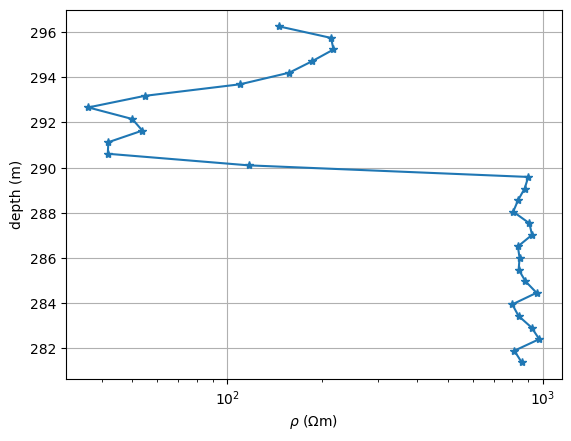

In [3]:
x, z, r = np.load('../data/x.npy'), np.load('../data/z.npy'), np.load('../data/r.npy')
fig, ax = plt.subplots()
ax.semilogx(r, z, "*-")
ax.set_xlabel(r"$\rho$ ($\Omega$m)")
ax.set_ylabel("depth (m)")
ax.grid(True)

## 6.2 Mesh generation

Analog to the previous notebooks, we create a mesh using the known surface electrode positions along the profile. 

18/09/26 - 13:50:58 - pyGIMLi - INFO - Found 2 regions.
18/09/26 - 13:50:58 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)


Mesh: Nodes: 2901 Cells: 5541 Boundaries: 8441


(<Axes: xlabel='$x$ in m', ylabel='$y$ in m'>,
 <matplotlib.colorbar.Colorbar at 0x1ee5c1624d0>)

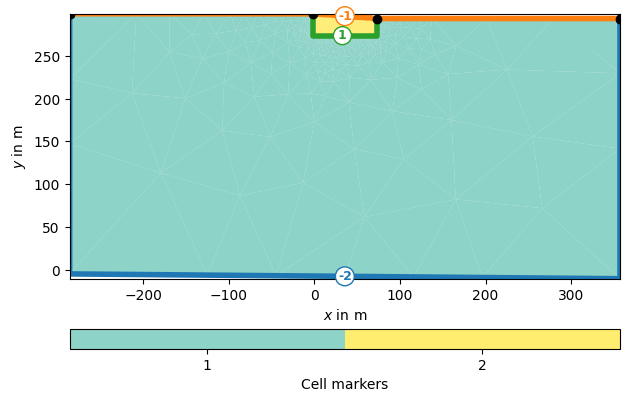

In [11]:
mesh = pg.load("../data/mesh_ERT.bms")
mgr = ert.ERTManager(data)
mgr.setMesh(mesh)
print(mesh)
pg.show(mesh, markers=True)

## 6.3 Individual inversion with borehole overlay

Next up, we load our smoothness-constrained ERT inversion result and plot the borehole information as an overlay on top.

We make use of `pg.viewer.mpl.draw1DColumn()` to visualize our borehole information:

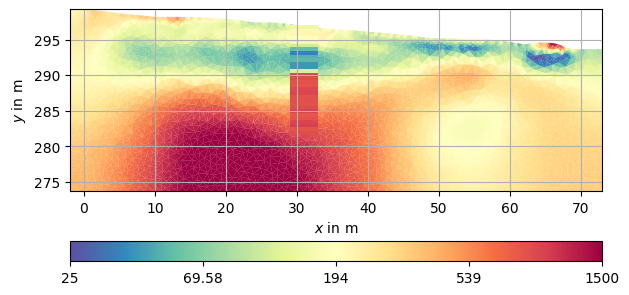

In [12]:
from pygimli.viewer.mpl import draw1DColumn

smooth_ERT = pg.load("../data/inv_ERT.vtk")

kw = dict(
    cMin=25, cMax=1500, logScale=True, cMap="Spectral_r",
    xlabel="x (m)", ylabel="y (m)")
ax, cb = pg.show(smooth_ERT, smooth_ERT["Resistivity"], **kw)
zz = np.abs(z[::-1])
iz = np.argsort(z[::-1])
dz = np.diff(zz[iz])
thk = np.hstack([dz, dz[-1]])
ztop = -zz[iz[0]]-dz[0]/2
colkw = dict(x=x[0], val=r[iz], thk=thk, width=4, ztopo=-ztop+sum(thk))
draw1DColumn(ax, **colkw, **kw)
ax.grid(True)

## 6.4) Include borehole constraints into the inversion

Next up, we want to **include the borehole information** into the inversion as constraints. 

For this, we have to call pyGIMLIs **`PriorModelling` and `JointModelling` frameworks**. The borehole data are considered as a separate data set in the following and thus the borehole data have a different forward operator ("fop"), called `fopBorehole` in this example. 

In [13]:
from pygimli.frameworks import PriorModelling, JointModelling
posVec = [pg.Pos(pos) for pos in zip(x, z)]
para = pg.Mesh(mgr.paraDomain)  # make a copy
para.setCellMarkers(pg.IVector(para.cellCount()))
fopBorehole = PriorModelling(para, posVec)

18/09/26 - 13:51:00 - pyGIMLi - INFO - Creating forward mesh from region infos.
18/09/26 - 13:51:00 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
18/09/26 - 13:51:00 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 11342 Cells: 22164 Boundaries: 16882
18/09/26 - 13:51:00 - pyGIMLi - INFO - Found 1 regions.


We now use the framework 'JointModelling' to **combine the ERT and the borehole data forward operators**. So we set up a new ERT modelling operator and join it with `fopDP`.

In [14]:
# fopERT = ert.ERTModelling()
# fopERT.setMesh(mesh)
# fopERT.setData(data) # not necessary as done by JointModelling
# fopJoint = JointModelling([fopERT, fopDP])
fopJoint = JointModelling([mgr.fop, fopBorehole])
# fopJoint.setMesh(para)
fopJoint.setData([data, pg.Vector(r)]) 

For the "combined inversion" of both the ERT and borehole data, **concatenate the data and error vectors**, create a new inversion instance, set logarithmic transformations and run the inversion.

18/09/26 - 13:51:04 - pyGIMLi - INFO - Starting inversion.
18/09/26 - 13:51:04 - pyGIMLi - INFO - fop: <pygimli.frameworks.modelling.JointModelling object at 0x000001EE5C140F90>
18/09/26 - 13:51:04 - pyGIMLi - INFO - Data transformation: Logarithmic transform
18/09/26 - 13:51:04 - pyGIMLi - INFO - Model transformation: Logarithmic transform
18/09/26 - 13:51:04 - pyGIMLi - INFO - min/max (data): 20.49/976
18/09/26 - 13:51:04 - pyGIMLi - INFO - min/max (error): 1.75%/20%
18/09/26 - 13:51:04 - pyGIMLi - INFO - min/max (start model): 144/144
18/09/26 - 13:51:36 - pyGIMLi - INFO - inv.iter 0 ... chi² =  409.63


--------------------------------------------------------------------------------
--------------------------------------------------------------------------------
inv.iter 1 ... 

18/09/26 - 13:51:45 - pyGIMLi - INFO - chi² =   70.31 (dPhi = 82.67%) lam: 20.0


--------------------------------------------------------------------------------
inv.iter 2 ... 

18/09/26 - 13:52:01 - pyGIMLi - INFO - chi² =   11.44 (dPhi = 82.69%) lam: 20.0


...

--------------------------------------------------------------------------------
inv.iter 4 ... 

18/09/26 - 13:52:34 - pyGIMLi - INFO - chi² =    1.25 (dPhi = 35.18%) lam: 20.0


--------------------------------------------------------------------------------
inv.iter 5 ... 

18/09/26 - 13:52:56 - pyGIMLi - INFO - chi² =    1.25 (dPhi = -0.03%) lam: 20.0


################################################################################
#                Abort criterion reached: dPhi = -0.03 (< 2.0%)                #
################################################################################


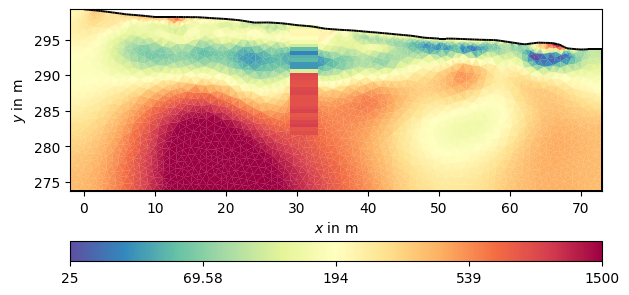

In [ ]:
dataVec = np.concatenate((data["rhoa"], r))
errorVec = np.concatenate((data["err"], np.ones_like(r)*0.2))
inv = pg.Inversion(fop=fopJoint, verbose=True)
transLog = pg.trans.TransLog()
inv.modelTrans = transLog
inv.dataTrans = transLog
inv.run(dataVec, errorVec, startModel=np.median(data['rhoa']))
ax, cb = pg.show(para, inv.model, **kw)
draw1DColumn(ax, **colkw, **kw)

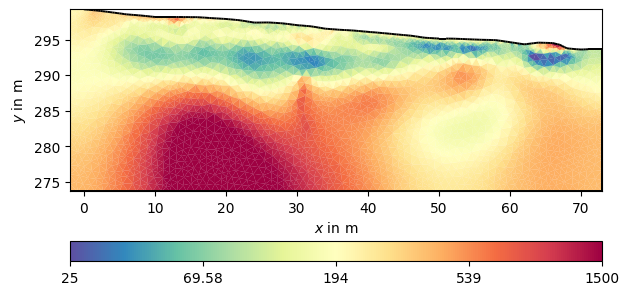

In [16]:
ax, cb = pg.show(para, inv.model, **kw)

As visible, we only have a **local improvement** of the model in the neighborhood of the borehole. Now we want to use **geostatistics** again to **horizontally extend** the effect of the 1D constraints:

16/09/26 - 14:07:30 - pyGIMLi - INFO - Starting inversion.


min/max(dweight) = 5/57.099
fop: <pygimli.frameworks.modelling.JointModelling object at 0x7038b11c3b00>
Data transformation: Logarithmic transform
Model transformation (cumulative):
	 0 Logarithmic LU transform, lower bound 0.0, upper bound 0.0
min/max (data): 20.49/998
min/max (error): 1.75%/20%
min/max (start model): 144/144
--------------------------------------------------------------------------------
use model trans from RegionManager


16/09/26 - 14:07:45 - pyGIMLi - INFO - Creating GeostatisticConstraintsMatrix for region 2 with: I=[5, 1], dip=0, strike=0
16/09/26 - 14:07:45 - pyGIMLi - INFO - Creating forward mesh from region infos.
16/09/26 - 14:07:45 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.


Calculating response for model: min = 144.315 max = 144.315
Using existing primary potentials.
Forward: time: 14.1231s
Response: min = 143.803 max = 145.188 mean = 144.314
Reciprocity rms(modelReciprocity) 0%, max: 0%
min/max(dweight) = 5/57.099
Building constraints matrix


16/09/26 - 14:07:45 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 11361 Cells: 22192 Boundaries: 16908


ModellingBase::setMesh() copying new mesh ... 0.0377554 s
FOP updating mesh dependencies ... 4.64e-05 s


16/09/26 - 14:09:34 - pyGIMLi - INFO - (C) Time for eigenvalue decomposition 108.0s
16/09/26 - 14:09:34 - pyGIMLi - INFO - Cache stored: /home/alexubuntuwsl/.cache/pygimli/11296615564219800701


constraint matrix of size(nBounds x nModel) 4531 x 4531
Calculating Jacobian matrix (forced=1)...Using existing subpotentials for createJacobian.
S(14/14-std::mt): 0.112906:time: 13.5602s
sens sum: median = 1.05702 min = 0.951192 max = 1.23925
... 13.6096 s
min data = 20.4942 max data = 997.712 (2933)
min error = 0.0175134 max error = 0.2 (2933)
min response = 143.803 max response = 145.188 (2933)
calc without reference model
0: rms/rrms(data, response) = 79.6142/45.3608%
0: chi^2(data, response, error, log) = 409.649
0: Phi = 1.2015e+06 + 7.55324e-25 * 20 = inv.iter 0 ... chi² =  409.65
1.2015e+06
--------------------------------------------------------------------------------
inv.iter 1 ... solve CGLSCDWWtrans with lambda = 20
Calculating response for model: min = 5.79913 max = 2595.05
Using existing primary potentials.
Forward: time: 16.8711s
Response: min = 16.1925 max = 347.261 mean = 130.898
Reciprocity rms(modelReciprocity) 2.00889%, max: 60.6704%
1: LS newModel: min = 5.79913; 

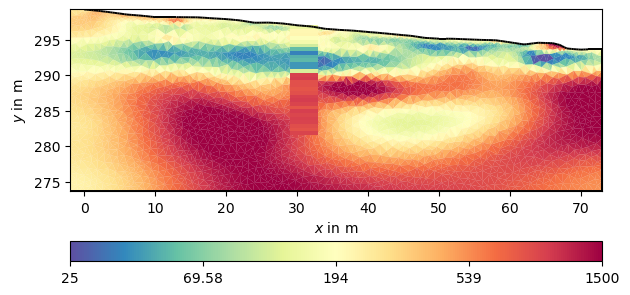

In [12]:
inv.setRegularization(2, correlationLengths=[5, 1])
model = inv.run(dataVec, errorVec, startModel=np.median(data['rhoa']))
ax, cb = pg.show(para, model, **kw)
draw1DColumn(ax, **colkw, **kw)